---
title: Considering equity in our solutions
image: image.png
execute: 
  enabled: true
---

In [1]:
from lokigi.site import SiteProblem
import pandas as pd

In [2]:
problem = SiteProblem()
problem.add_demand("../../../sample_data/brighton_demand.csv", demand_col="demand", location_id_col="LSOA")
problem.add_sites("../../../sample_data/brighton_sites_existing.geojson", candidate_id_col="site")
problem.add_travel_matrix(
    travel_matrix_df="../../../sample_data/brighton_travel_matrix_driving.csv",
    source_col="LSOA",
    from_unit="seconds",
    to_unit="minutes"
    )
problem.add_region_geometry_layer(
    "https://github.com/hsma-programme/h6_3d_facility_location_problems/raw/refs/heads/main/h6_3d_facility_location_problems/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    common_col="LSOA11NM"
    )

This time, we will add a new set of equity data. 

Before we add it to our problem, let's load in our equity dataset normally and have a look at it. 

This dataset has come from the UK government open geography portal and is licenced under the open government licence. You can take a look at it [here](https://geoportal.statistics.gov.uk/datasets/ce6b47c87d52468b8a97ecbad338f1e6_0/explore). 

In [3]:
equity_df = pd.read_csv("../../../sample_data/Index_of_Multiple_Deprivation_(Dec_2015)_Lookup_in_England.csv")

equity_df.head()

,ObjectId,LSOA11CD,LSOA11NM,IMD15
0,1,E01021988,Tendring 018A,1
1,2,E01012673,Blackpool 010A,2
2,3,E01012681,Blackpool 006A,3
3,4,E01024657,Thanet 001A,4
4,5,E01012751,Blackpool 013D,5


In [4]:
equity_df.tail()

,ObjectId,LSOA11CD,LSOA11NM,IMD15
32839,32840,E01028400,Rushcliffe 008D,32840
32840,32841,E01022863,Hart 007B,32841
32841,32842,E01016695,Wokingham 002F,32842
32842,32843,E01016676,Wokingham 001B,32843
32843,32844,E01016709,Wokingham 020E,32844


It looks like the IMD15 ranks every single LSOA. That's fine - we can ask lokigi to turn it into deciles for us!

We know that in this dataset, 1 = most deprived and 32844 = least deprived, so we set reverse=False (which is the default).

In [5]:
problem.add_equity_data(
    "../../../sample_data/Index_of_Multiple_Deprivation_(Dec_2015)_Lookup_in_England.csv",
    equity_col="IMD15",
    common_col="LSOA11NM",
    label="Indices of Multiple Deprivation",
    continuous_measure=True,
    reverse=False
    )

Let's see what our dataset looks like after loading it in. 

In [6]:
problem.show_equity_data()

,LSOA11NM,IMD15,IMD15_raw
0,Tendring 018A,1,1
1,Blackpool 010A,1,2
2,Blackpool 006A,1,3
3,Thanet 001A,1,4
4,Blackpool 013D,1,5
...,...,...,...
32839,Rushcliffe 008D,10,32840
32840,Hart 007B,10,32841
32841,Wokingham 002F,10,32842
32842,Wokingham 001B,10,32843


We can see we have the original column, but also a new column that has classified this data into deciles. 

Let's now plot this using our .plot_region_geometry_layer() method. We'll set plot_equity to True. 

<Axes: >

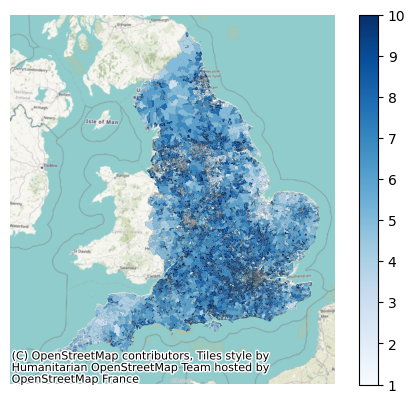

In [7]:
problem.plot_region_geometry_layer(plot_equity=True, linewidth=0.03)

However, this is not that useful to us as it's very zoomed out and showing the whole dataset (as our region geometry layer is for the whole of England too). 

However, we have passed in demand data for only our region of interest, so if we set 'plot_region_of_interest_only' to True, it will limit the output plot to that region. 

<Axes: >

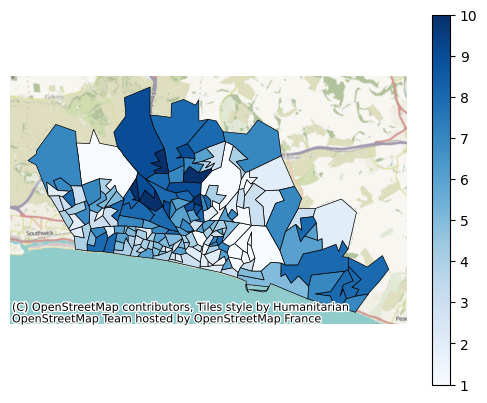

In [8]:
problem.plot_region_geometry_layer(
    plot_equity=True,
    plot_region_of_interest_only=True
    )

We can change the colourmap to something else. 

<Axes: >

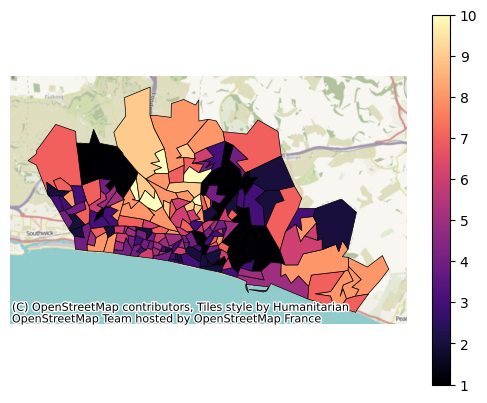

In [9]:
problem.plot_region_geometry_layer(
    plot_equity=True,
    plot_region_of_interest_only=True,
    cmap="magma"
    )

We can also opt to plot it in an interactive format instead. 

In [10]:
problem.plot_region_geometry_layer(
    plot_equity=True,
    plot_region_of_interest_only=True,
    interactive=True
    )

Let's now solve the problem. 

In [11]:
solutions = problem.solve(p=4, objectives="p_median", threshold_for_coverage=10)
solutions.show_solutions()

  0%|          | 0/15 [00:00<?, ?it/s]

,solution_rank,site_names,site_indices,unselected_site_names,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,total_cost,...,gap_absolute_weighted,gap_relative_weighted,avg_lower_third_bins,avg_middle_third_bins,avg_upper_third_bins,inter_tertile_ratio,gap_absolute_description,gap_relative_description,inter_tertile_description,problem_df
0,1,"[Site 1, Site 3, Site 4, Site 5]","[0, 2, 3, 4]","[Site 2, Site 6]",10,5.08,5.12,7.82,16.69,NaN,...,2.63,1.72,5.17,4.66,5.54,0.93,Spread of 2.6 minutes between best and worst g...,Significant Disparity (Worst group travels 72%...,Slightly Progressive (Most deprived travel 7% ...,LSOA Site 1 Sit...
1,2,"[Site 3, Site 4, Site 5, Site 6]","[2, 3, 4, 5]","[Site 1, Site 2]",10,5.11,5.05,7.42,16.69,NaN,...,2.44,1.66,5.22,4.76,4.55,1.15,Spread of 2.4 minutes between best and worst g...,Significant Disparity (Worst group travels 66%...,Slightly Inequitable (Most deprived travel 15%...,LSOA Site 3 Sit...
2,3,"[Site 2, Site 3, Site 4, Site 6]","[1, 2, 3, 5]","[Site 1, Site 5]",10,5.20,5.07,7.75,16.69,NaN,...,2.75,1.76,5.40,4.72,4.42,1.22,Spread of 2.8 minutes between best and worst g...,Significant Disparity (Worst group travels 76%...,Slightly Inequitable (Most deprived travel 22%...,LSOA Site 2 Sit...
3,4,"[Site 1, Site 2, Site 3, Site 4]","[0, 1, 2, 3]","[Site 5, Site 6]",10,5.22,5.21,8.34,16.69,NaN,...,2.80,1.77,5.37,4.67,5.61,0.96,Spread of 2.8 minutes between best and worst g...,Significant Disparity (Worst group travels 77%...,Balanced (Macro travel times are broadly equal),LSOA Site 1 Sit...
4,5,"[Site 1, Site 3, Site 4, Site 6]","[0, 2, 3, 5]","[Site 2, Site 5]",10,5.23,5.19,8.06,16.69,NaN,...,2.76,1.76,5.38,4.73,5.50,0.98,Spread of 2.8 minutes between best and worst g...,Significant Disparity (Worst group travels 76%...,Balanced (Macro travel times are broadly equal),LSOA Site 1 Sit...
5,6,"[Site 2, Site 3, Site 4, Site 5]","[1, 2, 3, 4]","[Site 1, Site 6]",10,5.28,5.33,8.32,16.69,NaN,...,2.10,1.49,5.35,4.95,5.46,0.98,Spread of 2.1 minutes between best and worst g...,Significant Disparity (Worst group travels 49%...,Balanced (Macro travel times are broadly equal),LSOA Site 2 Sit...
6,7,"[Site 1, Site 3, Site 5, Site 6]","[0, 2, 4, 5]","[Site 2, Site 4]",10,6.05,5.90,9.07,16.69,NaN,...,3.29,1.88,6.17,5.88,4.65,1.33,Spread of 3.3 minutes between best and worst g...,Significant Disparity (Worst group travels 88%...,Highly Inequitable (Most deprived travel 33% l...,LSOA Site 1 Sit...
7,8,"[Site 1, Site 2, Site 3, Site 6]","[0, 1, 2, 5]","[Site 4, Site 5]",10,6.14,5.92,9.33,16.69,NaN,...,3.60,1.99,6.35,5.83,4.52,1.40,Spread of 3.6 minutes between best and worst g...,Significant Disparity (Worst group travels 99%...,Highly Inequitable (Most deprived travel 40% l...,LSOA Site 1 Sit...
8,9,"[Site 1, Site 2, Site 3, Site 5]","[0, 1, 2, 4]","[Site 4, Site 6]",10,6.24,6.17,9.69,16.69,NaN,...,2.65,1.58,6.31,6.07,5.49,1.15,Spread of 2.7 minutes between best and worst g...,Significant Disparity (Worst group travels 58%...,Slightly Inequitable (Most deprived travel 15%...,LSOA Site 1 Sit...
9,10,"[Site 2, Site 3, Site 5, Site 6]","[1, 2, 4, 5]","[Site 1, Site 4]",10,6.33,6.17,9.26,16.69,NaN,...,3.74,2.09,6.43,6.25,4.49,1.43,Spread of 3.7 minutes between best and worst g...,Significant Disparity (Worst group travels 109...,Highly Inequitable (Most deprived travel 43% l...,LSOA Site 2 Sit...


The equity verdict columns above (`gap_absolute_description`, `gap_relative_description`, `inter_tertile_description`) are plain-English sentences, but pandas' default display truncates any string column wider than 50 characters with "...", so they get cut off mid-sentence in the raw table above. `show_solutions_summary()` surfaces the same verdicts as a few named columns instead; setting `display.max_colwidth` once keeps them from being cut off.

In [12]:
pd.set_option("display.max_colwidth", None)  # so long text columns aren't cut off with "..."

solutions.show_solutions_summary()[[
    "Equity gap (mins, best vs worst group)",
    "Equity verdict (best vs worst group)",
    "Equity verdict (most vs least deprived third)",
    ]]

,"Equity gap (mins, best vs worst group)",Equity verdict (best vs worst group),Equity verdict (most vs least deprived third)
0,2.6,Significant Disparity (Worst group travels 72% longer),Slightly Progressive (Most deprived travel 7% shorter)
1,2.4,Significant Disparity (Worst group travels 66% longer),Slightly Inequitable (Most deprived travel 15% longer)
2,2.8,Significant Disparity (Worst group travels 76% longer),Slightly Inequitable (Most deprived travel 22% longer)
3,2.8,Significant Disparity (Worst group travels 77% longer),Balanced (Macro travel times are broadly equal)
4,2.8,Significant Disparity (Worst group travels 76% longer),Balanced (Macro travel times are broadly equal)
5,2.1,Significant Disparity (Worst group travels 49% longer),Balanced (Macro travel times are broadly equal)
6,3.3,Significant Disparity (Worst group travels 88% longer),Highly Inequitable (Most deprived travel 33% longer)
7,3.6,Significant Disparity (Worst group travels 99% longer),Highly Inequitable (Most deprived travel 40% longer)
8,2.7,Significant Disparity (Worst group travels 58% longer),Slightly Inequitable (Most deprived travel 15% longer)
9,3.7,Significant Disparity (Worst group travels 109% longer),Highly Inequitable (Most deprived travel 43% longer)


Notice above that some columns -- `weighted_by_equity_group`, `unweighted_by_equity_group`, `coverage_by_equity_group`, and `max_cost_by_equity_group` -- hold a dict per solution, one entry per equity group. That is compact, but it is awkward to work with: you cannot sort, filter, or export it directly, and it will not survive a round-trip through CSV.

`coverage_by_equity_group` is demand-weighted, like its headline sibling `proportion_within_coverage_threshold` -- there's also a `coverage_regions_by_equity_group` counterpart that counts regions equally instead. See the [regional vs. demand-weighted coverage example](../coverage_metrics/index.ipynb) for how the two can differ.

`show_solutions()` can expand these into their own columns instead, named `<column>__<group>`, via `expand_dict_columns=True`.

In [13]:
solutions.show_solutions(expand_dict_columns=True)

solution_rank                        site_names  site_indices  \
0               1  [Site 1, Site 3, Site 4, Site 5]  [0, 2, 3, 4]   
1               2  [Site 3, Site 4, Site 5, Site 6]  [2, 3, 4, 5]   
2               3  [Site 2, Site 3, Site 4, Site 6]  [1, 2, 3, 5]   
3               4  [Site 1, Site 2, Site 3, Site 4]  [0, 1, 2, 3]   
4               5  [Site 1, Site 3, Site 4, Site 6]  [0, 2, 3, 5]   
5               6  [Site 2, Site 3, Site 4, Site 5]  [1, 2, 3, 4]   
6               7  [Site 1, Site 3, Site 5, Site 6]  [0, 2, 4, 5]   
7               8  [Site 1, Site 2, Site 3, Site 6]  [0, 1, 2, 5]   
8               9  [Site 1, Site 2, Site 3, Site 5]  [0, 1, 2, 4]   
9              10  [Site 2, Site 3, Site 5, Site 6]  [1, 2, 4, 5]   
10             11  [Site 1, Site 2, Site 4, Site 5]  [0, 1, 3, 4]   
11             12  [Site 2, Site 4, Site 5, Site 6]  [1, 3, 4, 5]   
12             13  [Site 1, Site 2, Site 4, Site 6]  [0, 1, 3, 5]   
13             14  [Site 1, Site 4, Site 5, Site 6]  [0, 3, 4, 5]   
14             15  [Site 1, Site 2, Site 5, Site 6]  [0, 1, 4, 5]   

   unselected_site_names  coverage_threshold  weighted_average  \
0       [Site 2, Site 6]                  10              5.08   
1       [Site 1, Site 2]                  10              5.11   
2       [Site 1, Site 5]                  10              5.20   
3       [Site 5, Site 6]                  10              5.22   
4       [Site 2, Site 5]                  10              5.23   
5       [Site 1, Site 6]                  10              5.28   
6       [Site 2, Site 4]                  10              6.05   
7       [Site 4, Site 5]                  10              6.14   
8       [Site 4, Site 6]                  10              6.24   
9       [Site 1, Site 4]                  10              6.33   
10      [Site 3, Site 6]                  10              6.63   
11      [Site 1, Site 3]                  10              6.66   
12      [Site 3, Site 5]                  10              6.83   
13      [Site 2, Site 3]                  10              6.91   
14      [Site 3, Site 4]                  10              7.67   

    unweighted_average  90th_percentile    max  total_cost  ...  \
0                 5.12             7.82  16.69         NaN  ...   
1                 5.05             7.42  16.69         NaN  ...   
2                 5.07             7.75  16.69         NaN  ...   
3                 5.21             8.34  16.69         NaN  ...   
4                 5.19             8.06  16.69         NaN  ...   
5                 5.33             8.32  16.69         NaN  ...   
6                 5.90             9.07  16.69         NaN  ...   
7                 5.92             9.33  16.69         NaN  ...   
8                 6.17             9.69  16.69         NaN  ...   
9                 6.17             9.26  16.69         NaN  ...   
10                6.43            11.32  21.71         NaN  ...   
11                6.37            11.32  21.71         NaN  ...   
12                6.48            11.58  22.86         NaN  ...   
13                6.56            12.26  21.71         NaN  ...   
14                7.27            11.67  21.71         NaN  ...   

    gap_absolute_weighted  gap_relative_weighted  avg_lower_third_bins  \
0                    2.63                   1.72                  5.17   
1                    2.44                   1.66                  5.22   
2                    2.75                   1.76                  5.40   
3                    2.80                   1.77                  5.37   
4                    2.76                   1.76                  5.38   
5                    2.10                   1.49                  5.35   
6                    3.29                   1.88                  6.17   
7                    3.60                   1.99                  6.35   
8                    2.65                   1.58                  6.31   
9                    3.74    

By default this only affects the DataFrame that is returned -- the underlying `solution_df` is untouched, so you can call `show_solutions()` again without the flag and get the compact version back.

If you would like the expansion to stick -- e.g. because you are about to export `solution_df` to CSV, or want to `rank_on` a specific equity group's column -- pass `inplace=True` as well, and it is written back onto `solution_df` permanently.

In [14]:
solutions.show_solutions(expand_dict_columns=True, inplace=True)
[c for c in solutions.solution_df.columns if "equity_group" in c]

['weighted_by_equity_group__1',
 'weighted_by_equity_group__2',
 'weighted_by_equity_group__3',
 'weighted_by_equity_group__4',
 'weighted_by_equity_group__5',
 'weighted_by_equity_group__6',
 'weighted_by_equity_group__7',
 'weighted_by_equity_group__8',
 'weighted_by_equity_group__9',
 'weighted_by_equity_group__10',
 'unweighted_by_equity_group__1',
 'unweighted_by_equity_group__2',
 'unweighted_by_equity_group__3',
 'unweighted_by_equity_group__4',
 'unweighted_by_equity_group__5',
 'unweighted_by_equity_group__6',
 'unweighted_by_equity_group__7',
 'unweighted_by_equity_group__8',
 'unweighted_by_equity_group__9',
 'unweighted_by_equity_group__10',
 'coverage_by_equity_group__1',
 'coverage_by_equity_group__2',
 'coverage_by_equity_group__3',
 'coverage_by_equity_group__4',
 'coverage_by_equity_group__5',
 'coverage_by_equity_group__6',
 'coverage_by_equity_group__7',
 'coverage_by_equity_group__8',
 'coverage_by_equity_group__9',
 'coverage_by_equity_group__10',
 'coverage_region

You can also look at the problem dataframe for each individual solution. Doing this, we can see that we have retained the IMD15 decile and raw ranking for each LSOA, which can support custom plots. 

In [15]:
example_problem_df = solutions.show_solutions()["problem_df"].iloc[0]

In [16]:
example_problem_df

,LSOA,Site 1,Site 3,Site 4,Site 5,min_cost,selected_site,within_threshold,demand,LSOA11NM,IMD15,IMD15_raw
0,Brighton and Hove 027E,12.898833,7.404833,8.197500,10.125667,7.404833,Site 3,True,3627,Brighton and Hove 027E,2,5040
1,Brighton and Hove 027F,12.623167,8.626167,9.351167,9.649500,8.626167,Site 3,True,2323,Brighton and Hove 027F,3,9104
2,Brighton and Hove 027A,12.720667,8.633000,6.840000,11.353833,6.840000,Site 4,True,2596,Brighton and Hove 027A,3,7483
3,Brighton and Hove 029E,12.393667,11.006000,6.328667,12.193000,6.328667,Site 4,True,3132,Brighton and Hove 029E,2,6218
4,Brighton and Hove 029D,11.097500,10.970000,5.216667,12.408333,5.216667,Site 4,True,2883,Brighton and Hove 029D,3,7018
...,...,...,...,...,...,...,...,...,...,...,...,...
160,Brighton and Hove 012A,7.442333,18.468500,8.652667,10.433667,7.442333,Site 1,True,2497,Brighton and Hove 012A,3,8891
161,Brighton and Hove 005C,7.830000,16.804000,9.490000,8.769167,7.830000,Site 1,True,2570,Brighton and Hove 005C,2,5951
162,Brighton and Hove 012B,7.742167,18.876667,8.952500,10.841833,7.742167,Site 1,True,2051,Brighton and Hove 012B,3,8814
163,Brighton and Hove 005A,9.458167,18.432167,11.068500,10.397333,9.458167,Site 1,True,1164,Brighton and Hove 005A,7,21094


We can also then use this to conduct some additional groupings if they are not provided in the solution level dataframe, though this one is. 

In [17]:
example_problem_df.groupby("IMD15")['min_cost'].agg("mean").round(2).reset_index()

,IMD15,min_cost
0,1,4.74
1,2,6.23
2,3,5.50
3,4,4.14
4,5,3.61
5,6,4.47
6,7,5.63
7,8,6.30
8,9,5.49
9,10,4.90


The `check_solution_equity()` method can do this automatically for the mean. 

In [18]:
solutions.check_solution_equity()

,IMD15,min_cost
0,1,4.74
1,2,6.23
2,3,5.50
3,4,4.14
4,5,3.61
5,6,4.47
6,7,5.63
7,8,6.30
8,9,5.49
9,10,4.90


And we can also opt to explore this as a plot. 

In [19]:
solutions.check_solution_equity(return_plot=True)

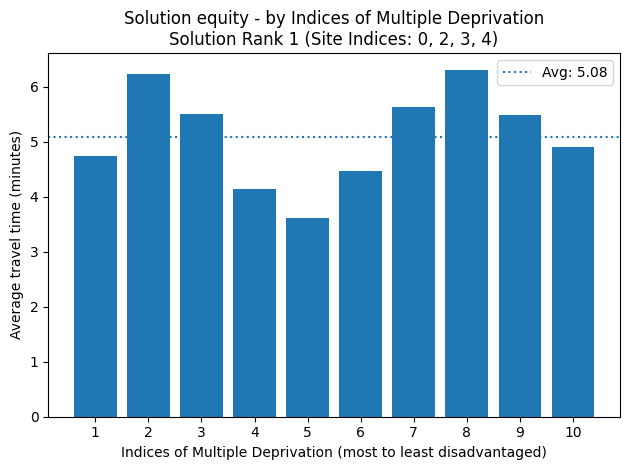

In [20]:
solutions.check_solution_equity(return_plot=True, interactive=False);

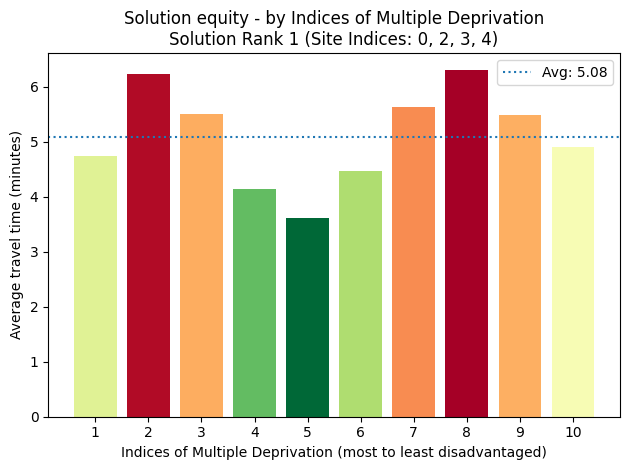

In [21]:
solutions.check_solution_equity(return_plot=True, interactive=False, colour_mode="gradient");

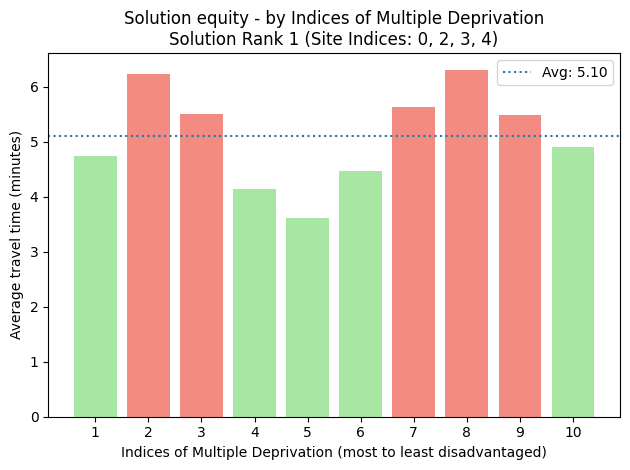

In [22]:
solutions.check_solution_equity(return_plot=True, interactive=False, colour_mode="above_below_avg");

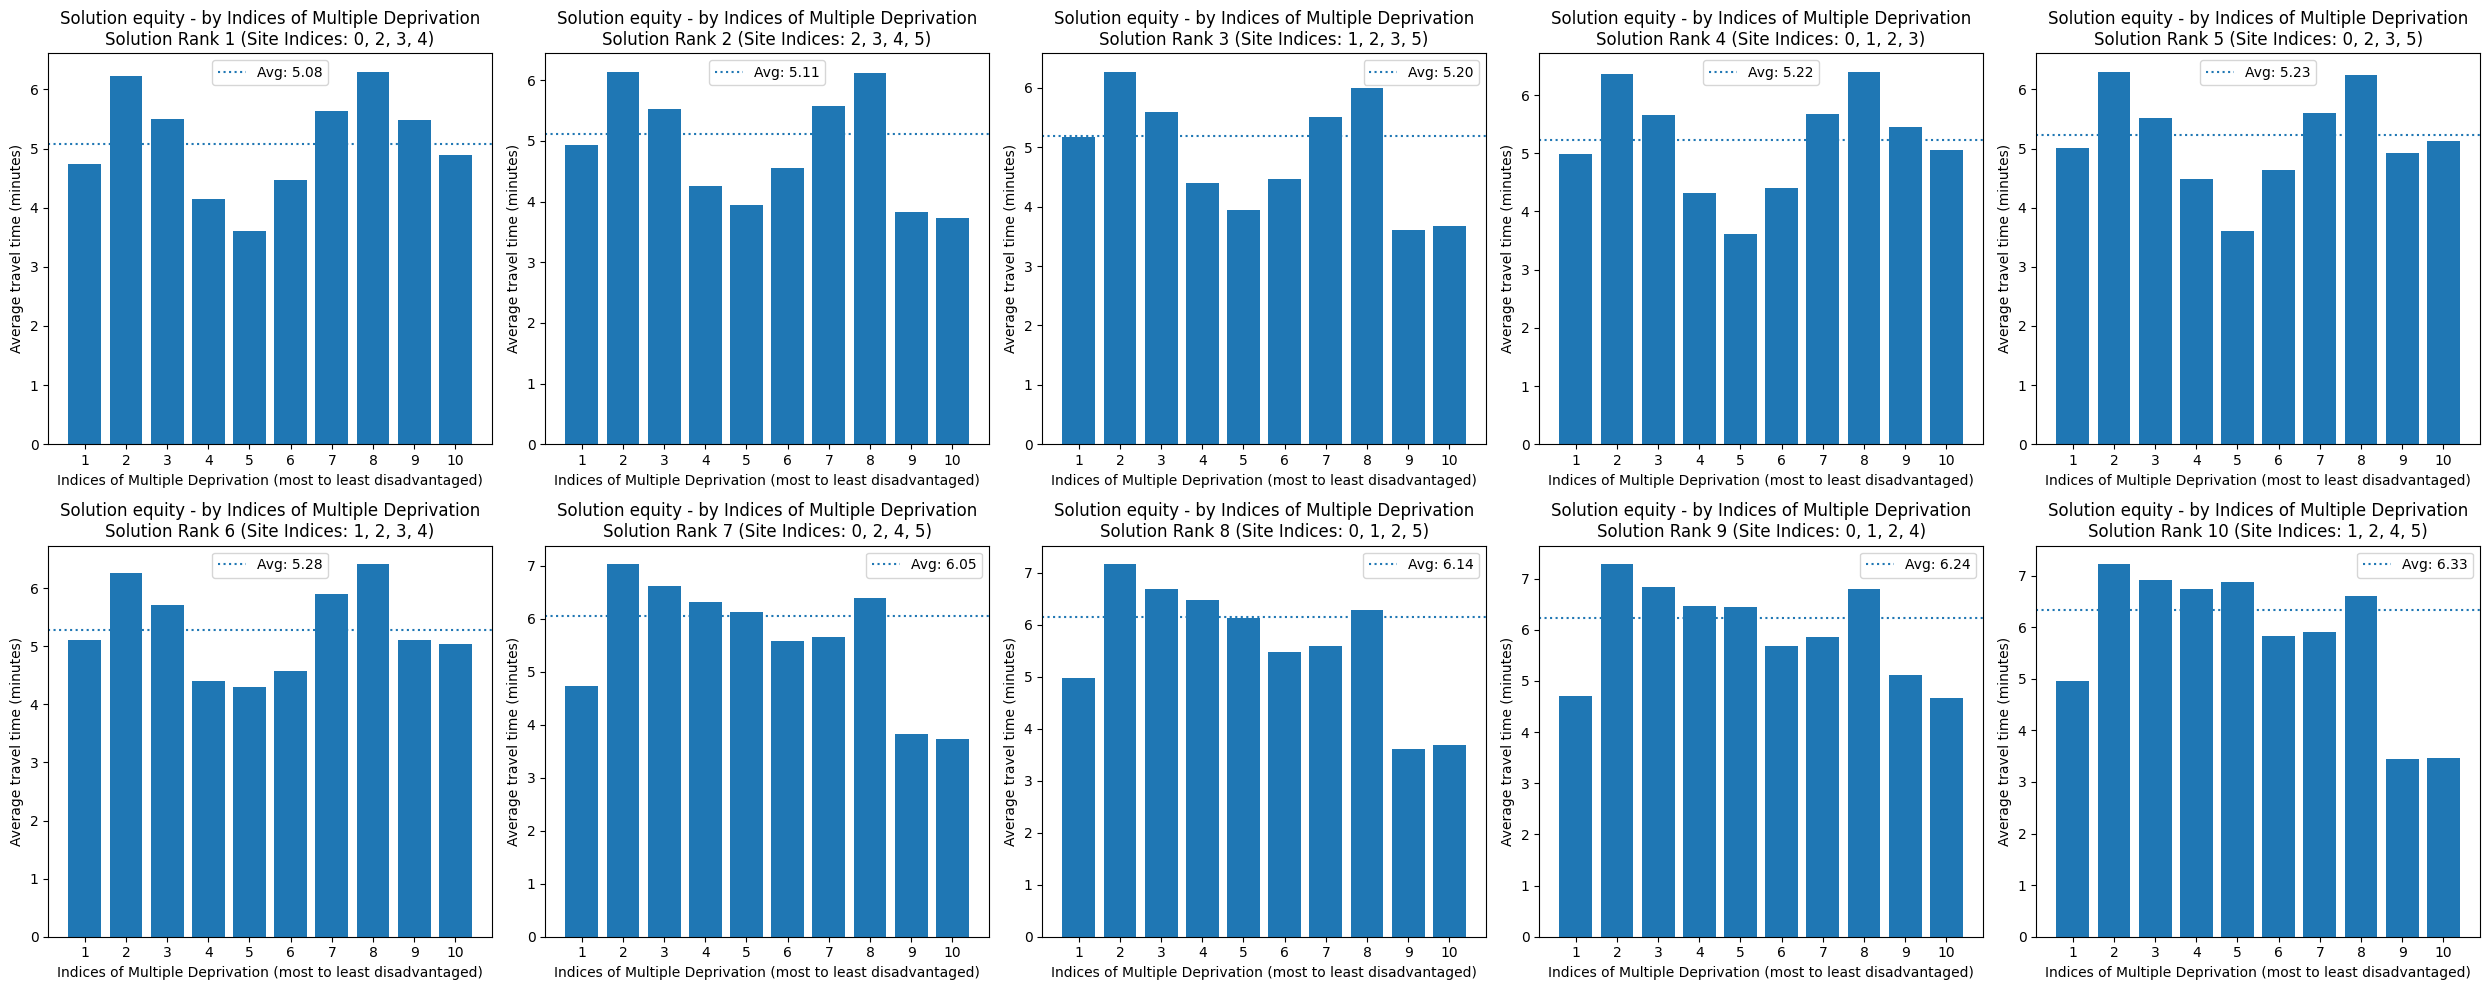

In [23]:
solutions.plot_top_n_solution_equity(cols=5, n=10);

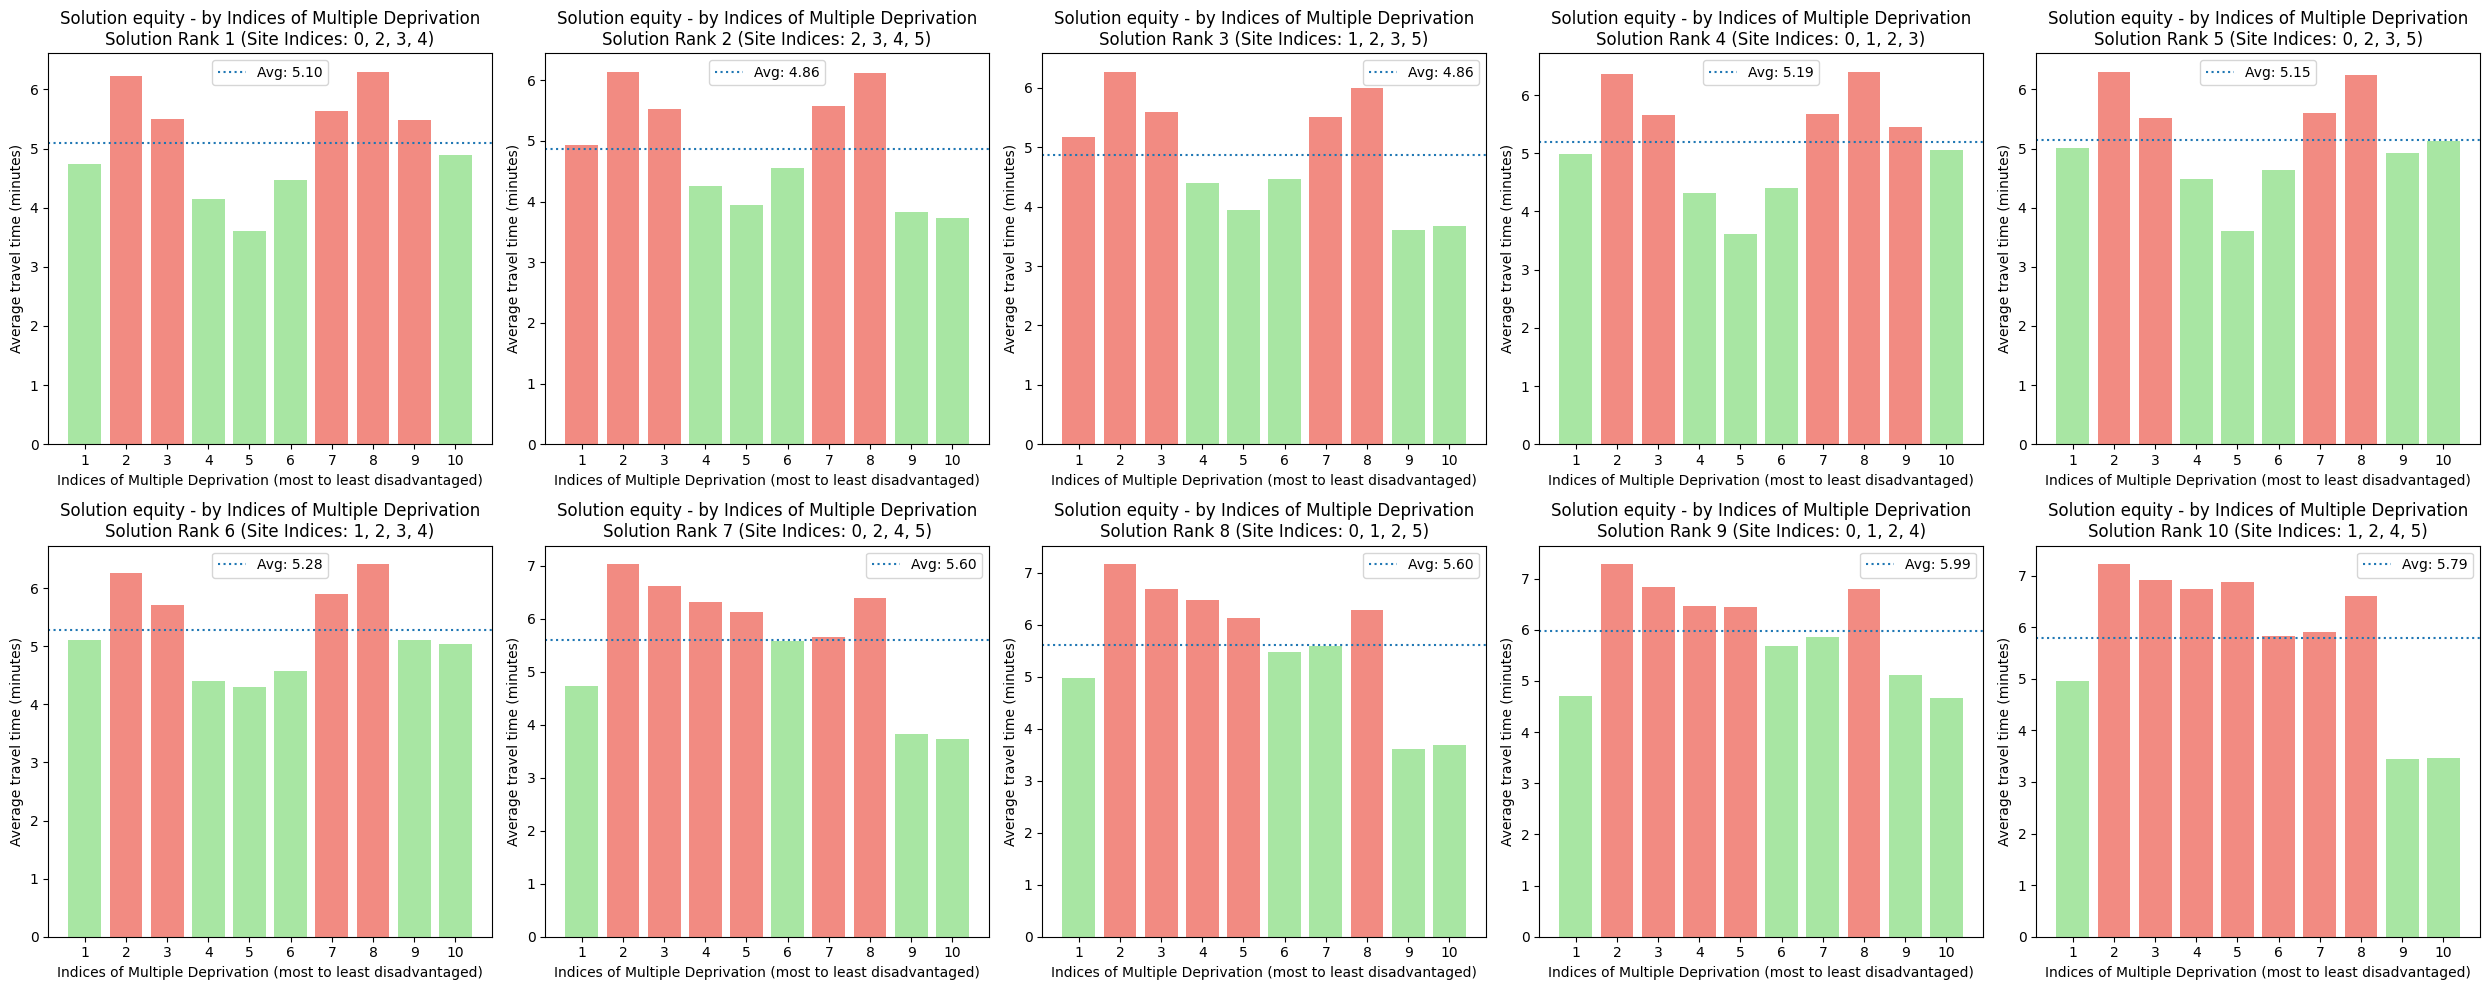

In [24]:
solutions.plot_top_n_solution_equity(cols=5, n=10, colour_mode="above_below_avg");

We can see for example that solution 2 is slightly worse for the most deprived group (IMD 1) than solution 1. 

In [25]:
example_problem_df

,LSOA,Site 1,Site 3,Site 4,Site 5,min_cost,selected_site,within_threshold,demand,LSOA11NM,IMD15,IMD15_raw
0,Brighton and Hove 027E,12.898833,7.404833,8.197500,10.125667,7.404833,Site 3,True,3627,Brighton and Hove 027E,2,5040
1,Brighton and Hove 027F,12.623167,8.626167,9.351167,9.649500,8.626167,Site 3,True,2323,Brighton and Hove 027F,3,9104
2,Brighton and Hove 027A,12.720667,8.633000,6.840000,11.353833,6.840000,Site 4,True,2596,Brighton and Hove 027A,3,7483
3,Brighton and Hove 029E,12.393667,11.006000,6.328667,12.193000,6.328667,Site 4,True,3132,Brighton and Hove 029E,2,6218
4,Brighton and Hove 029D,11.097500,10.970000,5.216667,12.408333,5.216667,Site 4,True,2883,Brighton and Hove 029D,3,7018
...,...,...,...,...,...,...,...,...,...,...,...,...
160,Brighton and Hove 012A,7.442333,18.468500,8.652667,10.433667,7.442333,Site 1,True,2497,Brighton and Hove 012A,3,8891
161,Brighton and Hove 005C,7.830000,16.804000,9.490000,8.769167,7.830000,Site 1,True,2570,Brighton and Hove 005C,2,5951
162,Brighton and Hove 012B,7.742167,18.876667,8.952500,10.841833,7.742167,Site 1,True,2051,Brighton and Hove 012B,3,8814
163,Brighton and Hove 005A,9.458167,18.432167,11.068500,10.397333,9.458167,Site 1,True,1164,Brighton and Hove 005A,7,21094


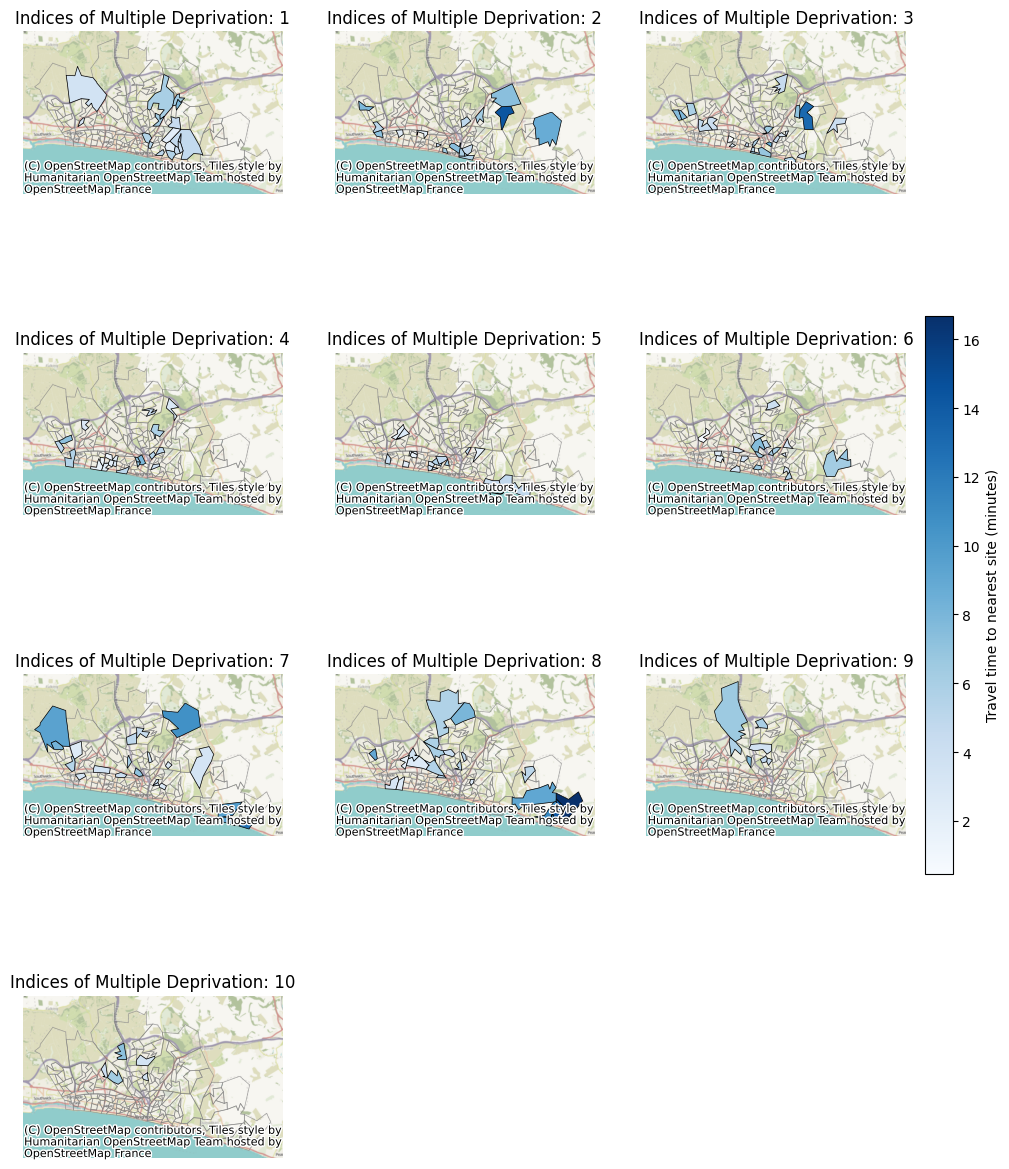

In [26]:
solutions.plot_combination_by_equity();

We can also choose to limit this to just certain groups.

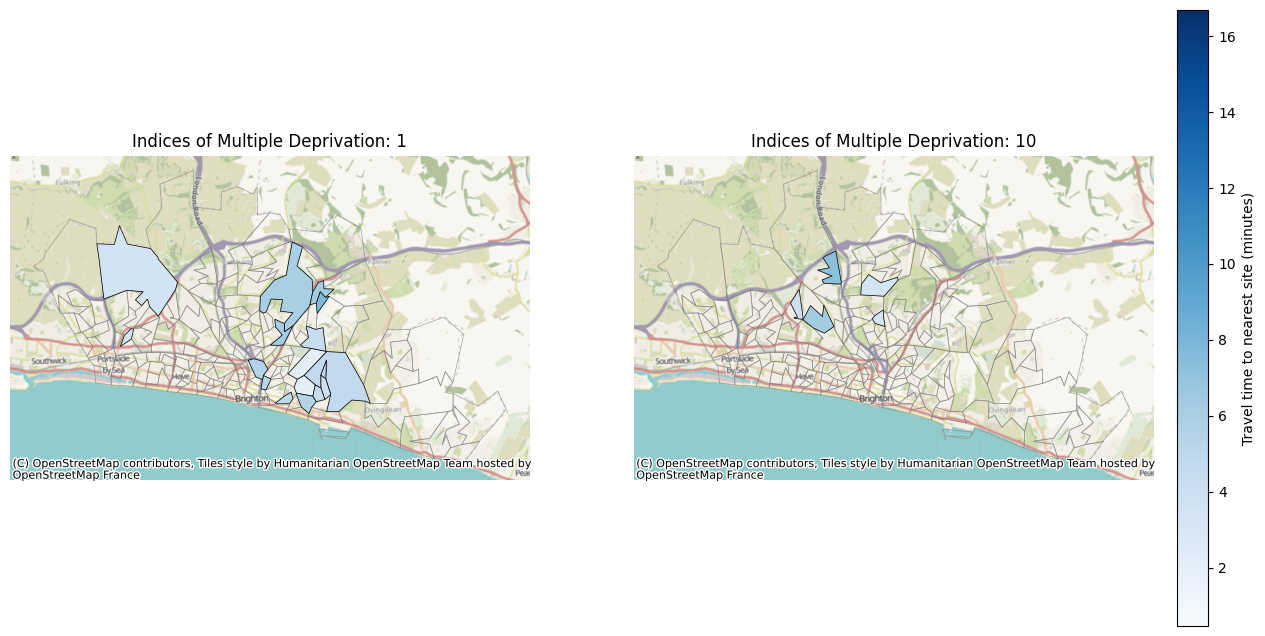

In [27]:
solutions.plot_combination_by_equity(groups_to_include=[1,10], figsize_multiplier=8);

We can also combine multiple groups to display in a single plot.

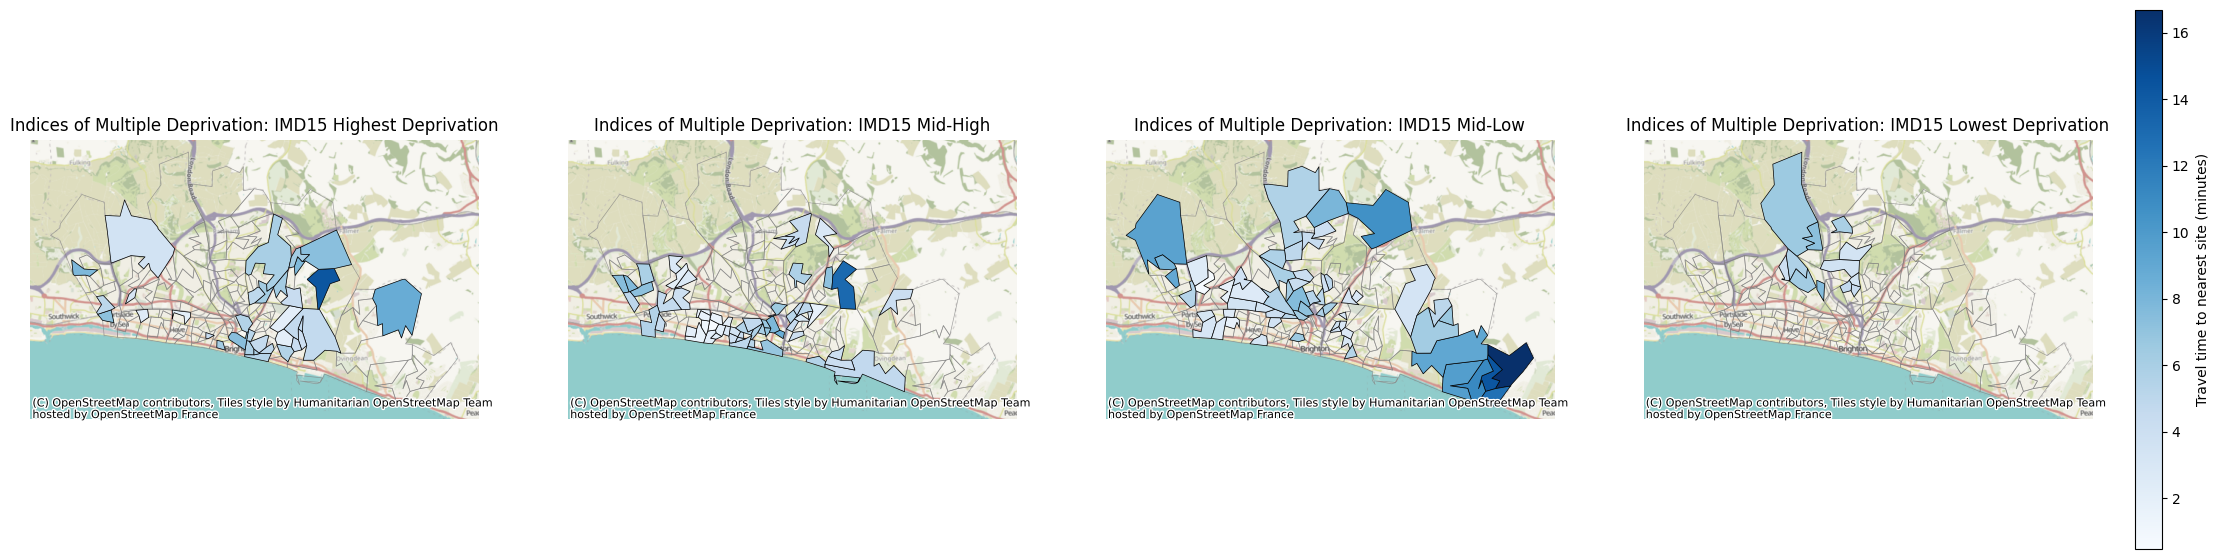

In [28]:
groupings = {
    "IMD15 Highest Deprivation": [1, 2],
    "IMD15 Mid-High": [3, 4, 5],
    "IMD15 Mid-Low": [6, 7, 8],
    "IMD15 Lowest Deprivation": [9, 10],
}

solutions.plot_combination_by_equity(groupings=groupings, figsize_multiplier=7, ncols=4);